In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [60]:
df_fear = pd.read_csv("cleaned_fear_greed.csv")
df_hist = pd.read_csv("cleaned_historical.csv")

print("Fear & Greed columns:", df_fear.columns.tolist())
print("Historical columns:", df_hist.columns.tolist())

Fear & Greed columns: ['timestamp', 'value', 'classification', 'date']
Historical columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [61]:

df_merged = pd.merge(df_fear, df_hist, left_on='date', right_on='Timestamp', how='inner')

print(f"Fear & Greed: {len(df_fear)} rows")
print(f"Historical:   {len(df_hist)} rows")
print(f"Merged:       {len(df_merged)} rows")
df_merged.head()

Fear & Greed: 2644 rows
Historical:   211224 rows
Merged:       184263 rows


,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,2023-03-28,59,Greed,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,2023-05-01,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
1,2023-03-28,59,Greed,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,2023-05-01,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
2,2023-03-28,59,Greed,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,2023-05-01,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
3,2023-11-14,69,Greed,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,2023-12-05,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14,2023-11-14
4,2023-11-14,69,Greed,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,2023-12-05,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.483987,2.340000e+14,2023-11-14


In [62]:
print(df_merged.shape)
df_merged.head()

(184263, 20)


,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,2023-03-28,59,Greed,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,2023-05-01,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
1,2023-03-28,59,Greed,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,2023-05-01,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
2,2023-03-28,59,Greed,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,2023-05-01,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28
3,2023-11-14,69,Greed,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,2023-12-05,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14,2023-11-14
4,2023-11-14,69,Greed,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,2023-12-05,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.483987,2.340000e+14,2023-11-14


In [63]:
df_merged = df_merged.drop(columns=['Timestamp', 'Timestamp IST', 'timestamp'], errors='ignore')

In [64]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184263 entries, 0 to 184262
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   value             184263 non-null  int64  
 1   classification    184263 non-null  object 
 2   date              184263 non-null  object 
 3   Account           184263 non-null  object 
 4   Coin              184263 non-null  object 
 5   Execution Price   184263 non-null  float64
 6   Size Tokens       184263 non-null  float64
 7   Size USD          184263 non-null  float64
 8   Side              184263 non-null  object 
 9   Start Position    184263 non-null  float64
 10  Direction         184263 non-null  object 
 11  Closed PnL        184263 non-null  float64
 12  Transaction Hash  184263 non-null  object 
 13  Order ID          184263 non-null  int64  
 14  Crossed           184263 non-null  bool   
 15  Fee               184263 non-null  float64
 16  Trade ID          18

In [65]:
df_merged.to_csv("merged_data.csv", index=False)
print("Merged data saved to merged_data.csv!")

Merged data saved to merged_data.csv!


In [66]:
df_merged['is_win'] = df_merged['Closed PnL'] > 0

df_merged['leverage'] = df_merged['Size USD'] / df_merged['Start Position']
df_merged['is_long'] = df_merged['Side'] == 'BUY'

print(df_merged['Side'].unique())
print(df_merged['Direction'].unique())

['BUY' 'SELL']
['Open Long' 'Open Short' 'Close Short' 'Close Long' 'Buy' 'Long > Short'
 'Short > Long' 'Sell' 'Auto-Deleveraging' 'Spot Dust Conversion'
 'Settlement']


In [67]:
df_merged['leverage'] = df_merged['leverage'].replace([np.inf, -np.inf], np.nan)

daily_metrics = df_merged.groupby(['date', 'Account', 'classification']).agg(
    daily_pnl       = ('Closed PnL', 'sum'),
    total_trades    = ('Closed PnL', 'count'),
    wins            = ('is_win', 'sum'),
    avg_trade_size  = ('Size USD', 'mean'),
    avg_leverage    = ('leverage', 'mean'),
    long_trades     = ('is_long', 'sum'),
    total_fee       = ('Fee', 'sum')
).reset_index()

daily_metrics['win_rate'] = daily_metrics['wins'] / daily_metrics['total_trades']
daily_metrics['long_ratio'] = daily_metrics['long_trades'] / daily_metrics['total_trades']

print(daily_metrics['avg_leverage'].describe())

count    7.700000e+01
mean     2.499649e+06
std      1.850956e+07
min     -9.847396e+05
25%     -4.727513e+00
50%      2.322558e+01
75%      2.940737e+03
max      1.614965e+08
Name: avg_leverage, dtype: float64


In [68]:
daily_metrics['avg_leverage'] = daily_metrics['avg_leverage'].clip(0, 200)
print(daily_metrics['avg_leverage'].describe())

count     77.000000
mean      93.959571
std       96.709473
min        0.000000
25%        0.000000
50%       23.225575
75%      200.000000
max      200.000000
Name: avg_leverage, dtype: float64


In [69]:
os.makedirs('output', exist_ok=True)
sns.set_style('darkgrid')

C:\Users\HP\AppData\Local\Temp\ipykernel_24796\2161475222.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=daily_metrics, x='sentiment', y='win_rate', ax=axes[1], ci=95)
C:\Users\HP\AppData\Local\Temp\ipykernel_24796\2161475222.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=daily_metrics, x='sentiment', y='total_trades', ax=axes[2], ci=95)


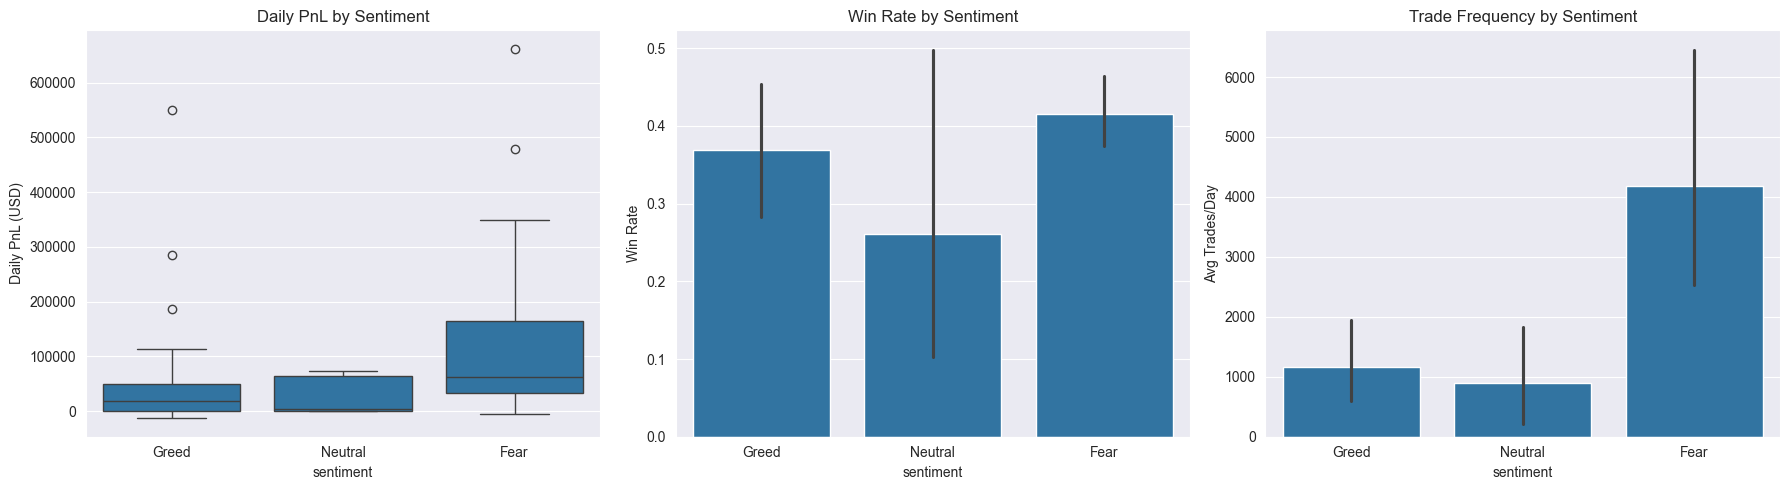


Mann-Whitney U test (PnL): stat=869.00, p-value=0.0009
Fear PnL mean: $125,367.02
Greed PnL mean: $51,300.35


In [70]:
daily_metrics['sentiment'] = daily_metrics['classification'].apply(
    lambda x: 'Fear' if 'Fear' in str(x) else ('Greed' if 'Greed' in str(x) else 'Neutral')
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=daily_metrics, x='sentiment', y='daily_pnl', ax=axes[0])
axes[0].set_title('Daily PnL by Sentiment')
axes[0].set_ylabel('Daily PnL (USD)')

sns.barplot(data=daily_metrics, x='sentiment', y='win_rate', ax=axes[1], ci=95)
axes[1].set_title('Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')

sns.barplot(data=daily_metrics, x='sentiment', y='total_trades', ax=axes[2], ci=95)
axes[2].set_title('Trade Frequency by Sentiment')
axes[2].set_ylabel('Avg Trades/Day')

plt.tight_layout()
plt.savefig('output/q1_fear_vs_greed_performance.png', dpi=150, bbox_inches='tight')
plt.show()

fear_pnl = daily_metrics[daily_metrics['sentiment'] == 'Fear']['daily_pnl']
greed_pnl = daily_metrics[daily_metrics['sentiment'] == 'Greed']['daily_pnl']
stat, pval = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f"\nMann-Whitney U test (PnL): stat={stat:.2f}, p-value={pval:.4f}")
print(f"Fear PnL mean: ${fear_pnl.mean():,.2f}")
print(f"Greed PnL mean: ${greed_pnl.mean():,.2f}")

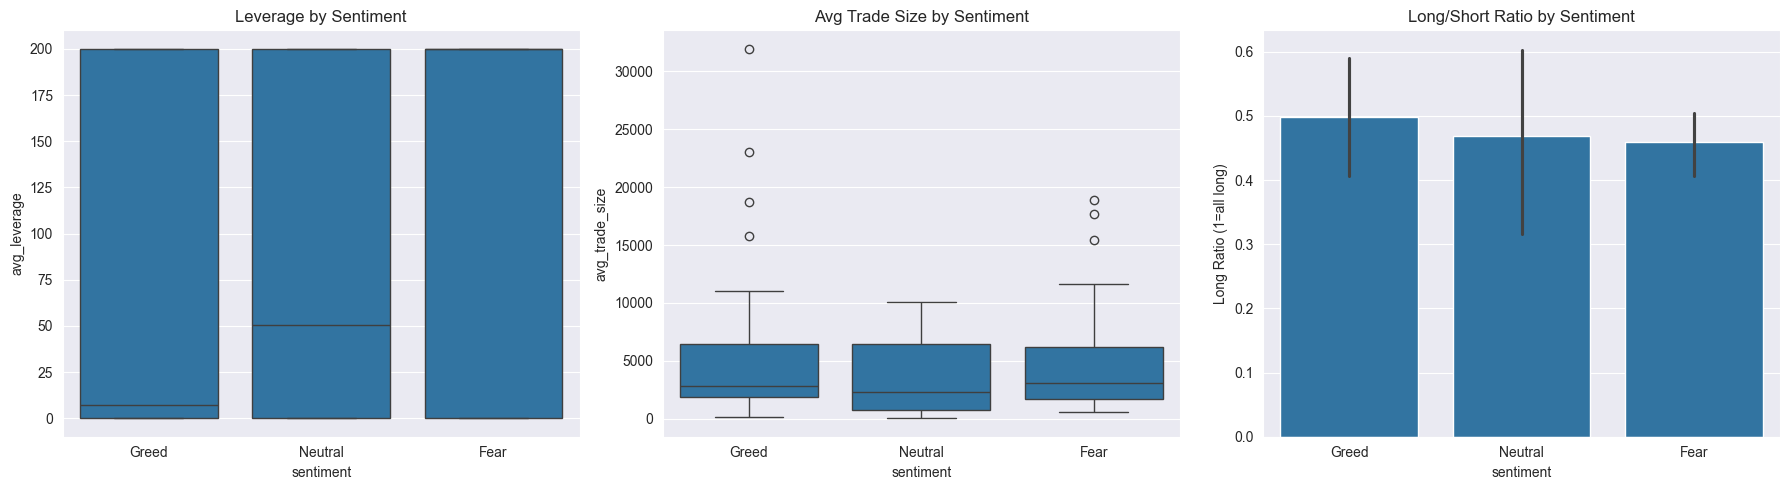

           avg_leverage  avg_trade_size  long_ratio
sentiment                                          
Fear         114.236874     4808.424260    0.459352
Greed         77.805143     5464.391445    0.498847
Neutral       87.564586     3746.940151    0.468967


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=daily_metrics, x='sentiment', y='avg_leverage', ax=axes[0])
axes[0].set_title('Leverage by Sentiment')

sns.boxplot(data=daily_metrics, x='sentiment', y='avg_trade_size', ax=axes[1])
axes[1].set_title('Avg Trade Size by Sentiment')

sns.barplot(data=daily_metrics, x='sentiment', y='long_ratio', ax=axes[2], errorbar=('ci', 95))
axes[2].set_title('Long/Short Ratio by Sentiment')
axes[2].set_ylabel('Long Ratio (1=all long)')

plt.tight_layout()
plt.savefig('output/q2_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(daily_metrics.groupby('sentiment')[['avg_leverage', 'avg_trade_size', 'long_ratio']].mean())

In [72]:
trader_stats = df_merged.groupby('Account').agg(
    total_pnl      = ('Closed PnL', 'sum'),
    total_trades   = ('Closed PnL', 'count'),
    win_rate       = ('is_win', 'mean'),
    avg_leverage   = ('leverage', 'mean'),
    avg_size       = ('Size USD', 'mean'),
    pnl_std        = ('Closed PnL', 'std')
).reset_index()

trader_stats['avg_leverage'] = trader_stats['avg_leverage'].clip(0, 200)

trader_stats['leverage_seg'] = np.where(
    trader_stats['avg_leverage'] > trader_stats['avg_leverage'].median(),
    'High Leverage', 'Low Leverage'
)

trader_stats['freq_seg'] = np.where(
    trader_stats['total_trades'] > trader_stats['total_trades'].median(),
    'Frequent', 'Infrequent'
)

trader_stats['consistency_seg'] = np.where(
    trader_stats['pnl_std'] < trader_stats['pnl_std'].median(),
    'Consistent', 'Inconsistent'
)

print(trader_stats[['Account', 'total_pnl', 'total_trades', 'win_rate', 
                     'leverage_seg', 'freq_seg', 'consistency_seg']].head(10))
print(f"\nTotal traders: {len(trader_stats)}")

                                      Account      total_pnl  total_trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  467023.632853          3818   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   53235.080476          3853   
2  0x271b280974205ca63b716753467d5a371de622ab   30716.874259          1146   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  147712.491426         13266   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  140138.065685          3234   
5  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   17340.013356           617   
6  0x39cef799f8b69da1995852eea189df24eb5cae3c  115181.659799          3589   
7  0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   18692.725444           332   
8  0x420ab45e0bd8863569a5efbb9c05d91f40624641   47723.472730           383   
9  0x430f09841d65beb3f27765503d0f850b8bce7713  174547.091386          1051   

   win_rate  leverage_seg    freq_seg consistency_seg  
0  0.359612  Low Leverage    Frequent    Inconsistent  
1  0.443031  Low Leverage    

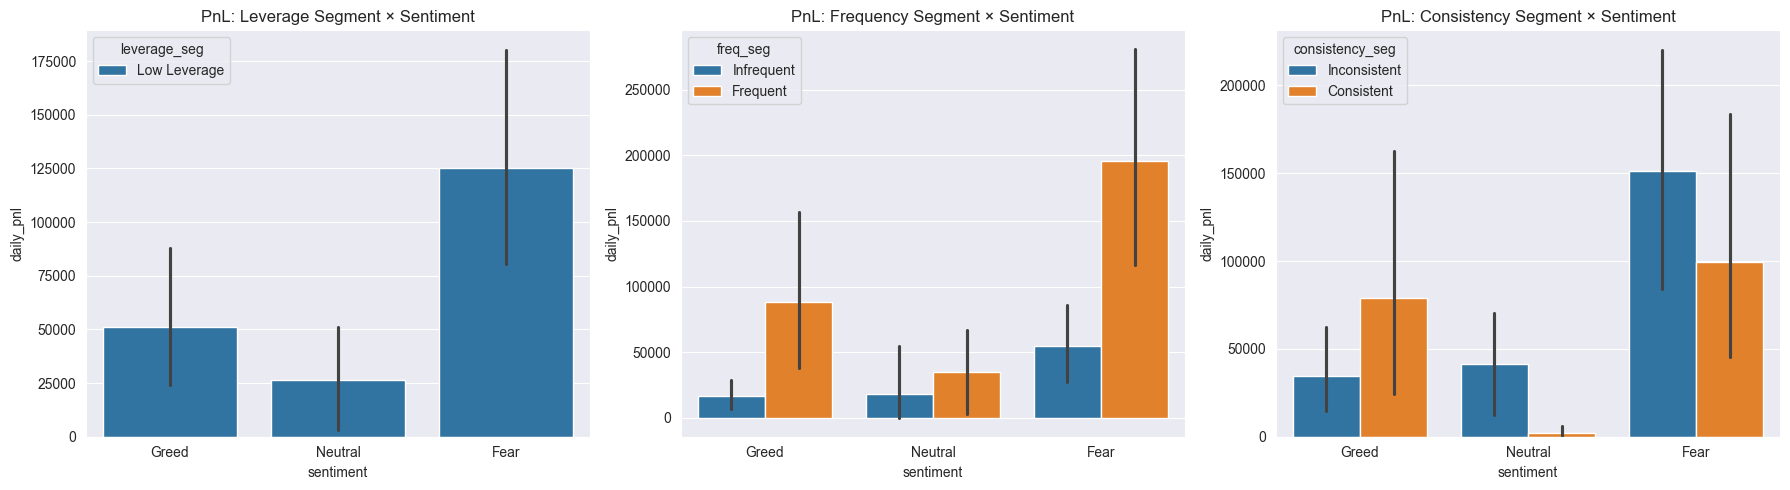


--- PnL by Leverage Segment × Sentiment ---
leverage_seg   Low Leverage
sentiment                  
Fear          125367.017873
Greed          51300.349470
Neutral        26585.393837

--- PnL by Frequency Segment × Sentiment ---
freq_seg        Frequent    Infrequent
sentiment                             
Fear       195657.913854  55076.121892
Greed       88194.870090  16347.645726
Neutral     35086.014154  18084.773520

--- PnL by Consistency Segment × Sentiment ---
consistency_seg    Consistent   Inconsistent
sentiment                                   
Fear             99561.299007  151172.736739
Greed            79083.059047   34389.134945
Neutral           2070.820452   41294.137868


In [73]:
daily_metrics = daily_metrics.merge(
    trader_stats[['Account', 'leverage_seg', 'freq_seg', 'consistency_seg']], 
    on='Account', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=daily_metrics, x='sentiment', y='daily_pnl', 
            hue='leverage_seg', ax=axes[0], errorbar=('ci', 95))
axes[0].set_title('PnL: Leverage Segment × Sentiment')

sns.barplot(data=daily_metrics, x='sentiment', y='daily_pnl', 
            hue='freq_seg', ax=axes[1], errorbar=('ci', 95))
axes[1].set_title('PnL: Frequency Segment × Sentiment')

sns.barplot(data=daily_metrics, x='sentiment', y='daily_pnl', 
            hue='consistency_seg', ax=axes[2], errorbar=('ci', 95))
axes[2].set_title('PnL: Consistency Segment × Sentiment')

plt.tight_layout()
plt.savefig('output/q3_segments_x_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- PnL by Leverage Segment × Sentiment ---")
print(daily_metrics.groupby(['sentiment', 'leverage_seg'])['daily_pnl'].mean().unstack())
print("\n--- PnL by Frequency Segment × Sentiment ---")
print(daily_metrics.groupby(['sentiment', 'freq_seg'])['daily_pnl'].mean().unstack())
print("\n--- PnL by Consistency Segment × Sentiment ---")
print(daily_metrics.groupby(['sentiment', 'consistency_seg'])['daily_pnl'].mean().unstack())

In [74]:

print("=" * 60)
print("STRATEGY RECOMMENDATIONS")
print("=" * 60)

print("""
STRATEGY 1: "Fear = Opportunity for Frequent Traders"
-------------------------------------------------------
- Frequent traders earn 2.2x more on Fear days ($195K vs $88K)
- Recommendation: Frequent traders should INCREASE trade 
  frequency during Fear periods, as market fear creates 
  more profitable trading opportunities for active traders.
- Keep position sizes moderate but stay active.

STRATEGY 2: "Consistent Traders — Stay the Course"
-------------------------------------------------------
- Consistent traders show stable PnL regardless of sentiment
  (Fear: $99K vs Greed: $79K — only 1.25x difference)
- Recommendation: Consistent traders should NOT change 
  strategy based on sentiment. Their edge is sentiment-neutral.
- Avoid increasing leverage during Fear days — the extra 
  leverage (114x vs 78x) doesn't benefit this segment.

BONUS RULE: "Reduce Leverage on Greed Days"
-------------------------------------------------------
- Overall PnL drops significantly on Greed days ($51K vs $125K)
- Traders use lower leverage on Greed days (78x) but still 
  underperform — suggesting Greed days have unfavorable conditions.
- Rule of thumb: Cap leverage at 50x on Greed/Extreme Greed days.
""")

STRATEGY RECOMMENDATIONS

STRATEGY 1: "Fear = Opportunity for Frequent Traders"
-------------------------------------------------------
- Frequent traders earn 2.2x more on Fear days ($195K vs $88K)
- Recommendation: Frequent traders should INCREASE trade 
  frequency during Fear periods, as market fear creates 
  more profitable trading opportunities for active traders.
- Keep position sizes moderate but stay active.

STRATEGY 2: "Consistent Traders — Stay the Course"
-------------------------------------------------------
- Consistent traders show stable PnL regardless of sentiment
  (Fear: $99K vs Greed: $79K — only 1.25x difference)
- Recommendation: Consistent traders should NOT change 
  strategy based on sentiment. Their edge is sentiment-neutral.
- Avoid increasing leverage during Fear days — the extra 
  leverage (114x vs 78x) doesn't benefit this segment.

BONUS RULE: "Reduce Leverage on Greed Days"
-------------------------------------------------------
- Overall PnL drops s

['date', 'Account', 'classification', 'daily_pnl', 'total_trades', 'wins', 'avg_trade_size', 'avg_leverage', 'long_trades', 'total_fee', 'win_rate', 'long_ratio', 'sentiment', 'leverage_seg', 'freq_seg', 'consistency_seg']
=== Random Forest Results ===
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.90      1.00      0.95        19

    accuracy                           0.92        24
   macro avg       0.95      0.80      0.85        24
weighted avg       0.92      0.92      0.91        24



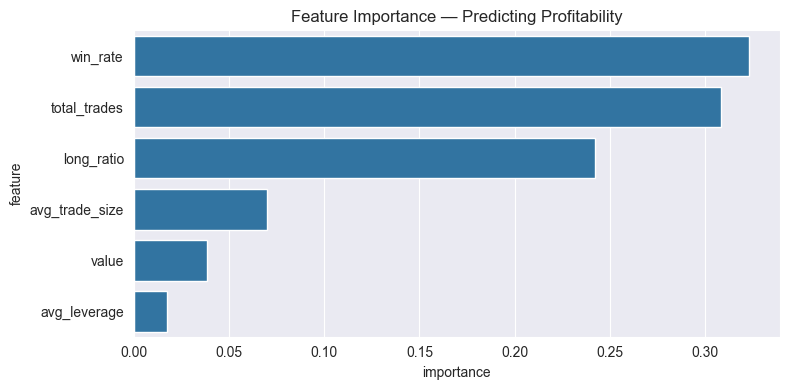

          feature  importance
5        win_rate    0.323119
1    total_trades    0.308485
4      long_ratio    0.241973
3  avg_trade_size    0.070175
0           value    0.038733
2    avg_leverage    0.017516


In [75]:

print(daily_metrics.columns.tolist())

date_sentiment = df_merged.groupby('date')['value'].first().reset_index()
daily_metrics = daily_metrics.merge(date_sentiment, on='date', how='left')

features = ['value', 'total_trades', 'avg_leverage', 'avg_trade_size', 'long_ratio', 'win_rate']
daily_metrics['profitable'] = (daily_metrics['daily_pnl'] > 0).astype(int)
X = daily_metrics[features].fillna(0)
y = daily_metrics['profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred))

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=feat_imp, x='importance', y='feature', ax=ax)
ax.set_title('Feature Importance — Predicting Profitability')
plt.tight_layout()
plt.savefig('output/bonus_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp)

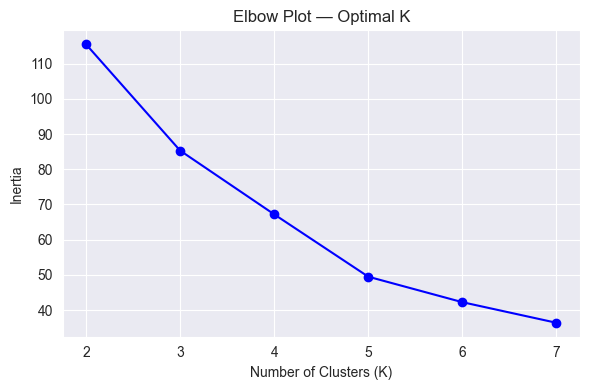

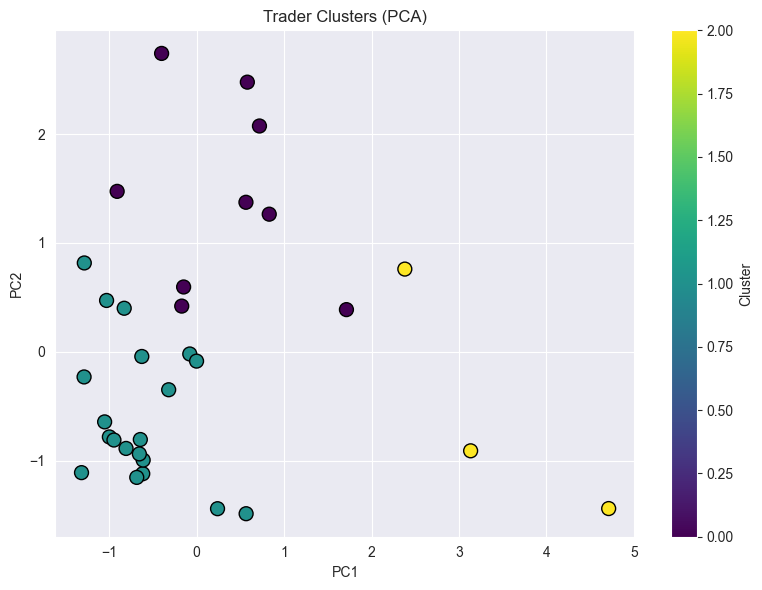


=== Cluster Profiles ===
         total_pnl  total_trades  win_rate  avg_leverage  avg_size
cluster                                                           
0        264423.36       4516.44      0.49         28.94   9459.25
1         83844.30       3574.05      0.37        150.61   3098.17
2        688614.79      24044.67      0.41        133.33   2899.63

Cluster sizes: {1: 20, 0: 9, 2: 3}


In [76]:
cluster_features = ['total_pnl', 'total_trades', 'win_rate', 'avg_leverage', 'avg_size']
X_cluster = trader_stats[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(K_range, inertias, 'bo-')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Plot — Optimal K')
plt.tight_layout()
plt.savefig('output/bonus_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

km = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_stats['cluster'] = km.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=trader_stats['cluster'], 
                     cmap='viridis', s=100, edgecolors='black')
ax.set_title('Trader Clusters (PCA)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('output/bonus_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Cluster Profiles ===")
print(trader_stats.groupby('cluster')[cluster_features].mean().round(2))
print("\nCluster sizes:", trader_stats['cluster'].value_counts().to_dict())